### CodeAlpha Task 2
---

**Author** : Aditi Singh

---

TASK : Car Price Prediction with Machine Learning

● Collect car-related features like brand goodwill, horsepower, mileage, etc.

● Train a regression model to predict car prices based on these features.

● Handle data preprocessing, feature engineering, and model evaluation

● Use Python libraries like Pandas, Scikit-learn and Matplotlib for the workflow.

● Understand real-world applications of machine learning in price prediction.

In [174]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [175]:
#Load the dataset
df= pd.read_csv('/content/car data.csv')

In [176]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [177]:
df.shape

(301, 9)

In [178]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [179]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [180]:
print("=== Categorical Distributions ===")
for col in ['Fuel_Type','Selling_type','Transmission','Owner']:
    print(f"{col}: {df[col].value_counts().to_dict()}")

=== Categorical Distributions ===
Fuel_Type: {'Petrol': 239, 'Diesel': 60, 'CNG': 2}
Selling_type: {'Dealer': 195, 'Individual': 106}
Transmission: {'Manual': 261, 'Automatic': 40}
Owner: {0: 290, 1: 10, 3: 1}


## EDA

In [181]:
# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2d3748',
    'axes.labelcolor':  '#94a3b8',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#e2e8f0',
    'grid.color':       '#2d3748',
    'grid.linestyle':   '--',
    'grid.alpha':       0.4,
})

ACCENT = '#7c3aed'; GOLD = '#f59e0b'; GREEN = '#10b981'
RED = '#ef4444'; BLUE = '#3b82f6'; TEXT = '#e2e8f0'; MUTED = '#94a3b8'

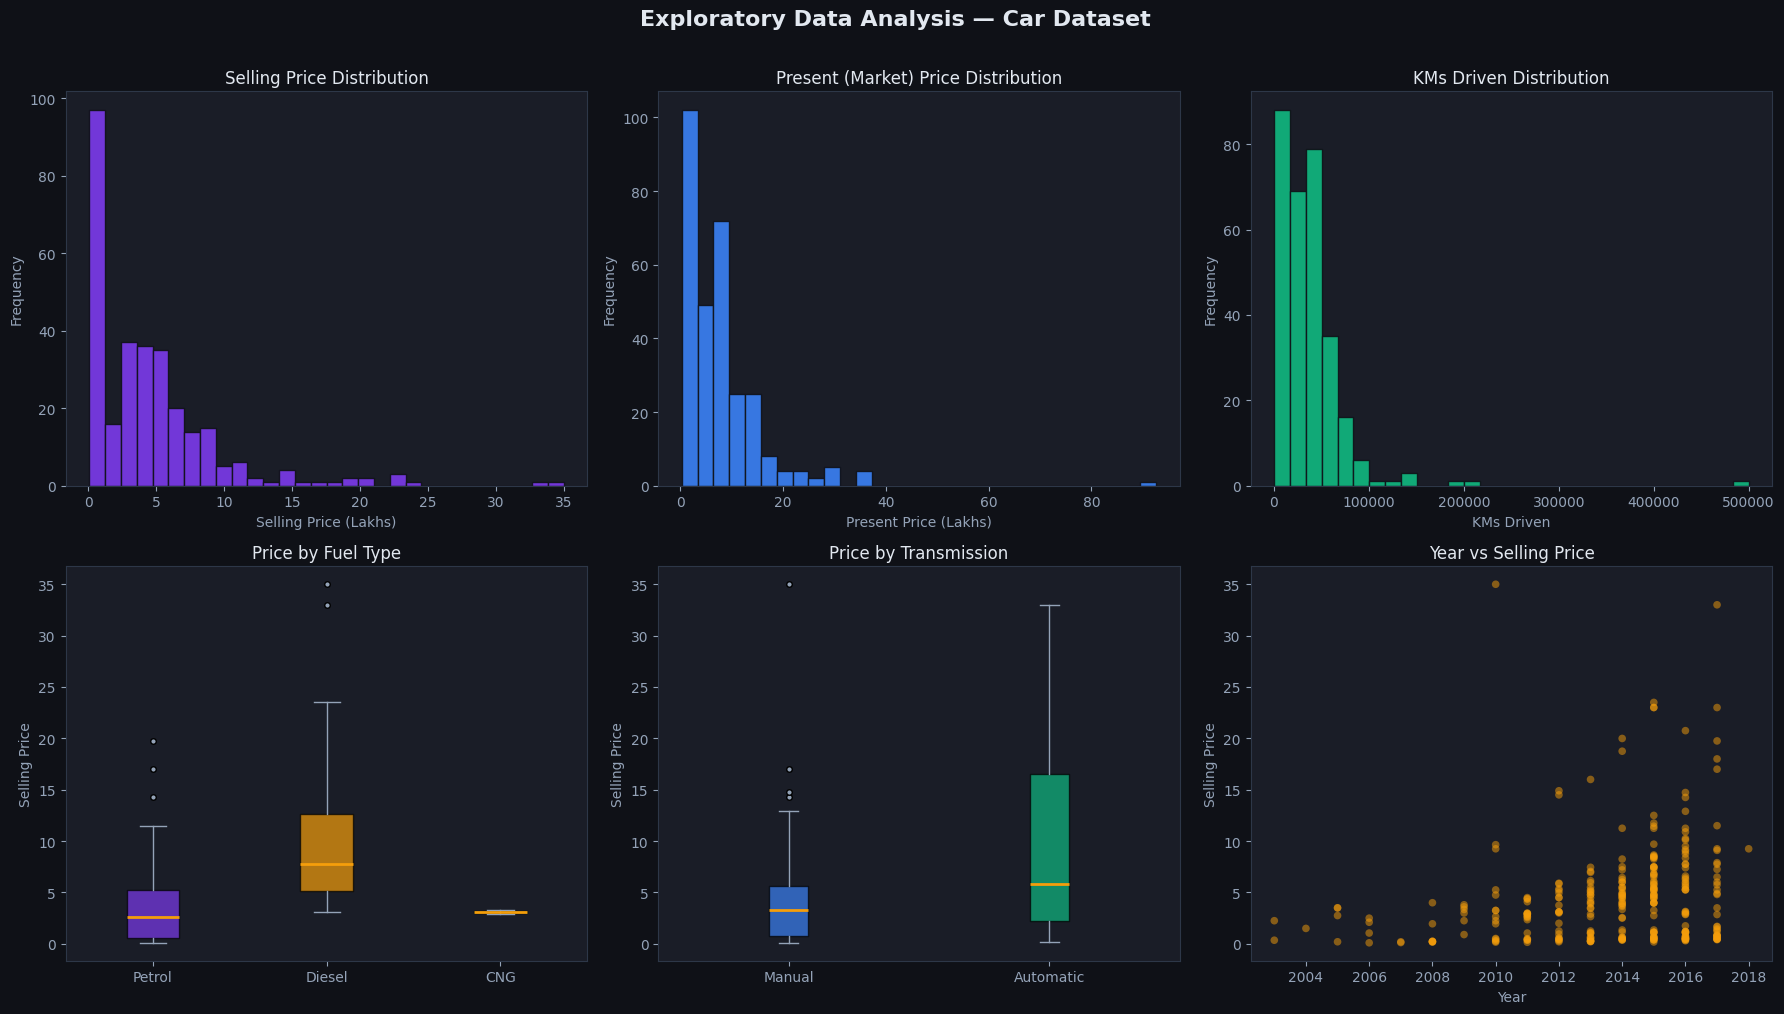

In [182]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Exploratory Data Analysis — Car Dataset', fontsize=16, color=TEXT, fontweight='bold', y=1.01)

# 1. Selling Price Distribution
axes[0,0].hist(df['Selling_Price'], bins=30, color=ACCENT, edgecolor='#0f1117', alpha=0.9)
axes[0,0].set_title('Selling Price Distribution', color=TEXT)
axes[0,0].set_xlabel('Selling Price (Lakhs)'); axes[0,0].set_ylabel('Frequency')

# 2. Present Price Distribution
axes[0,1].hist(df['Present_Price'], bins=30, color=BLUE, edgecolor='#0f1117', alpha=0.9)
axes[0,1].set_title('Present (Market) Price Distribution', color=TEXT)
axes[0,1].set_xlabel('Present Price (Lakhs)'); axes[0,1].set_ylabel('Frequency')

# 3. Driven KMs Distribution
axes[0,2].hist(df['Driven_kms'], bins=30, color=GREEN, edgecolor='#0f1117', alpha=0.9)
axes[0,2].set_title('KMs Driven Distribution', color=TEXT)
axes[0,2].set_xlabel('KMs Driven'); axes[0,2].set_ylabel('Frequency')

# 4. Selling Price by Fuel Type
fuel_data = [df[df['Fuel_Type']==ft]['Selling_Price'].values for ft in df['Fuel_Type'].unique()]
bp = axes[1,0].boxplot(fuel_data, patch_artist=True,
    boxprops=dict(facecolor=ACCENT, alpha=0.7),
    medianprops=dict(color=GOLD, linewidth=2),
    whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
    flierprops=dict(markerfacecolor=MUTED, markersize=4))
for patch, c in zip(bp['boxes'], [ACCENT, GOLD, GREEN]):
    patch.set_facecolor(c)
axes[1,0].set_xticklabels(df['Fuel_Type'].unique())
axes[1,0].set_title('Price by Fuel Type', color=TEXT); axes[1,0].set_ylabel('Selling Price')

# 5. Selling Price by Transmission
trans_data = [df[df['Transmission']==t]['Selling_Price'].values for t in df['Transmission'].unique()]
bp2 = axes[1,1].boxplot(trans_data, patch_artist=True,
    boxprops=dict(facecolor=BLUE, alpha=0.7),
    medianprops=dict(color=GOLD, linewidth=2),
    whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
    flierprops=dict(markerfacecolor=MUTED, markersize=4))
for patch, c in zip(bp2['boxes'], [BLUE, GREEN]):
    patch.set_facecolor(c)
axes[1,1].set_xticklabels(df['Transmission'].unique())
axes[1,1].set_title('Price by Transmission', color=TEXT); axes[1,1].set_ylabel('Selling Price')

# 6. Year vs Selling Price
axes[1,2].scatter(df['Year'], df['Selling_Price'], alpha=0.5, color=GOLD, s=30, edgecolors='none')
axes[1,2].set_title('Year vs Selling Price', color=TEXT)
axes[1,2].set_xlabel('Year'); axes[1,2].set_ylabel('Selling Price')

plt.tight_layout()
plt.show()

## Feature Engineering

> Creating domain-informed features that encode real-world knowledge:
> - **Car_Age**: Newer cars depreciate less
> - **KMS_per_Year**: Usage intensity — high usage = more wear
> - **Brand_Goodwill**: Resale value retention ratio (higher = better brand)

In [183]:
# Car Age
df['Car_Age']= 2024 - df['Year']

In [184]:
df['Kms_per_year']   = df['Driven_kms'] / (df['Car_Age'] + 1)

In [185]:
df['Brand_good_will']= df['Selling_Price'] / df['Present_Price'].replace(0, 0.01)

### Brand Goodwill Feature Engineering

To capture the value retention capability of different car brands, a new feature called **Brand Goodwill** was created.

Brand Goodwill is calculated as:

Brand Goodwill = Selling Price / Present Price

A higher value indicates that a car retains a larger proportion of its original value over time, reflecting stronger market demand and brand reputation. This engineered feature helps the model capture brand-related influences on resale value and improve price prediction performance.

In [186]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,Kms_per_year,Brand_good_will
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,10,2454.545455,0.599284
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,11,3583.333333,0.497904
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,7,862.500000,0.736041
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,13,371.428571,0.686747
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,10,3859.090909,0.669578


In [187]:
# Encode all 3 categorical columns (Selling_type was missing before)
le = LabelEncoder()
df['Fuel_Type']     = le.fit_transform(df['Fuel_Type'])
df['Selling_type']  = le.fit_transform(df['Selling_type'])
df['Transmission']  = le.fit_transform(df['Transmission'])

In [188]:
df[['Car_Age','Kms_per_year','Brand_good_will','Fuel_Type','Selling_type','Transmission']].head()

,Car_Age,Kms_per_year,Brand_good_will,Fuel_Type,Selling_type,Transmission
0,10,2454.545455,0.599284,2,0,1
1,11,3583.333333,0.497904,1,0,1
2,7,862.500000,0.736041,2,0,1
3,13,371.428571,0.686747,2,0,1
4,10,3859.090909,0.669578,1,0,1


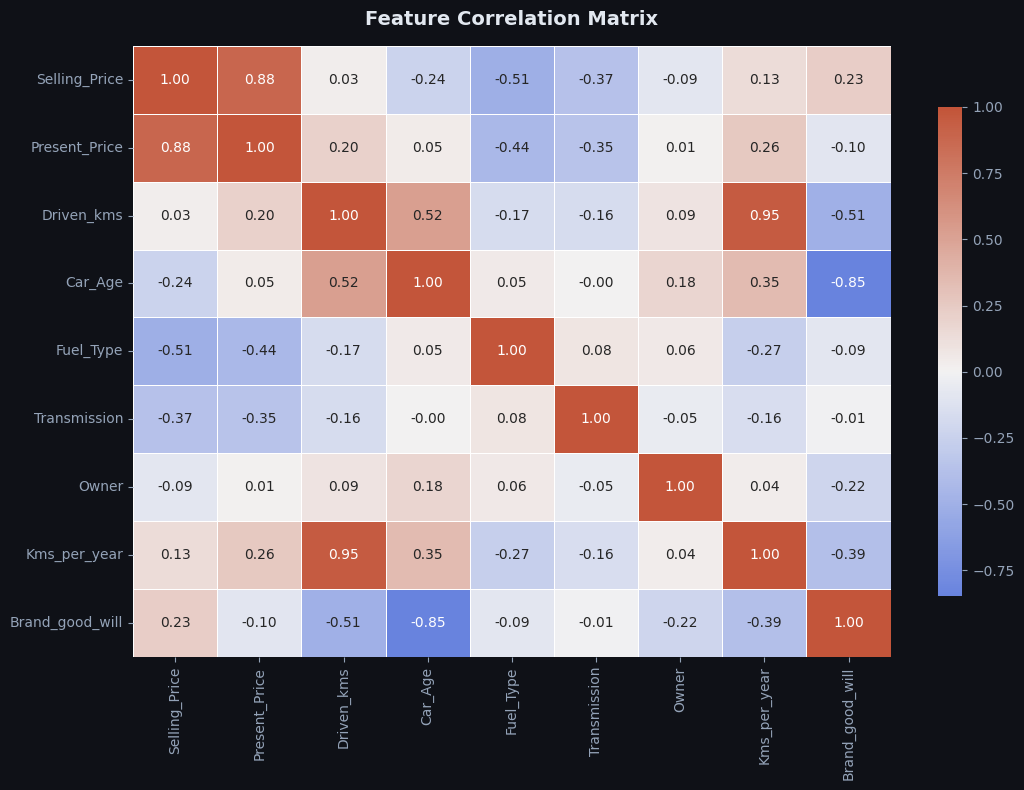


Top correlations with Selling_Price:
Selling_Price      1.000
Present_Price      0.879
Brand_good_will    0.234
Kms_per_year       0.135
Driven_kms         0.029
Owner             -0.088
Car_Age           -0.236
Transmission      -0.367
Fuel_Type         -0.509
Name: Selling_Price, dtype: float64


In [189]:
num_cols = ['Selling_Price','Present_Price','Driven_kms','Car_Age',
            'Fuel_Type','Transmission','Owner','Kms_per_year','Brand_good_will']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
cmap = sns.diverging_palette(260, 20, as_cmap=True)
sns.heatmap(corr, ax=ax, cmap=cmap, center=0, annot=True, fmt='.2f',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\nTop correlations with Selling_Price:")
print(corr['Selling_Price'].sort_values(ascending=False).round(3))

##  Train / Test Split & Scaling

In [190]:
features = ['Present_Price', 'Driven_kms', 'Car_Age',
            'Fuel_Type', 'Selling_type', 'Transmission', 'Owner',
            'Kms_per_year', 'Brand_good_will']

X = df[features]
y = df['Selling_Price']

print(f"Features : {features}")
print(f"X shape  : {X.shape}")
print(f"y range  : {y.min():.2f}  —  {y.max():.2f} Lakhs")

Features : ['Present_Price', 'Driven_kms', 'Car_Age', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Kms_per_year', 'Brand_good_will']
X shape  : (301, 9)
y range  : 0.10  —  35.00 Lakhs


In [191]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Train samples : {X_train.shape[0]}")
print(f"Test  samples : {X_test.shape[0]}")

Train samples : 240
Test  samples : 61


In [192]:
# Scale only for Linear Regression
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

## Train Multiple Regression Models

In [193]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree':     DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}
print(f"{'MODEL':<25} {'R²':>8} {'MAE':>8} {'RMSE':>8}")
print("="*55)

for name, model in models.items():
    # Linear Regression uses scaled data; trees use raw data
    if name == 'Linear Regression':
        model.fit(X_train_sc, y_train)
        pred = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    r2   = r2_score(y_test, pred)
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    results[name] = {'R2': r2, 'MAE': mae, 'RMSE': rmse, 'pred': pred}
    print(f"{name:<25} {r2:>8.4f} {mae:>8.4f} {rmse:>8.4f}")

best_name = max(results, key=lambda k: results[k]['R2'])
print(f"\n Best Model: {best_name}  (R² = {results[best_name]['R2']:.4f})")

MODEL                           R²      MAE     RMSE
Linear Regression           0.8813   1.0664   1.6537
Decision Tree               0.9545   0.6626   1.0241
Random Forest               0.9797   0.3982   0.6835

 Best Model: Random Forest  (R² = 0.9797)


## Model Comparison — Visualisation

/tmp/ipykernel_995/1646945776.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=15, ha='right')
/tmp/ipykernel_995/1646945776.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=15, ha='right')
/tmp/ipykernel_995/1646945776.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=15, ha='right')


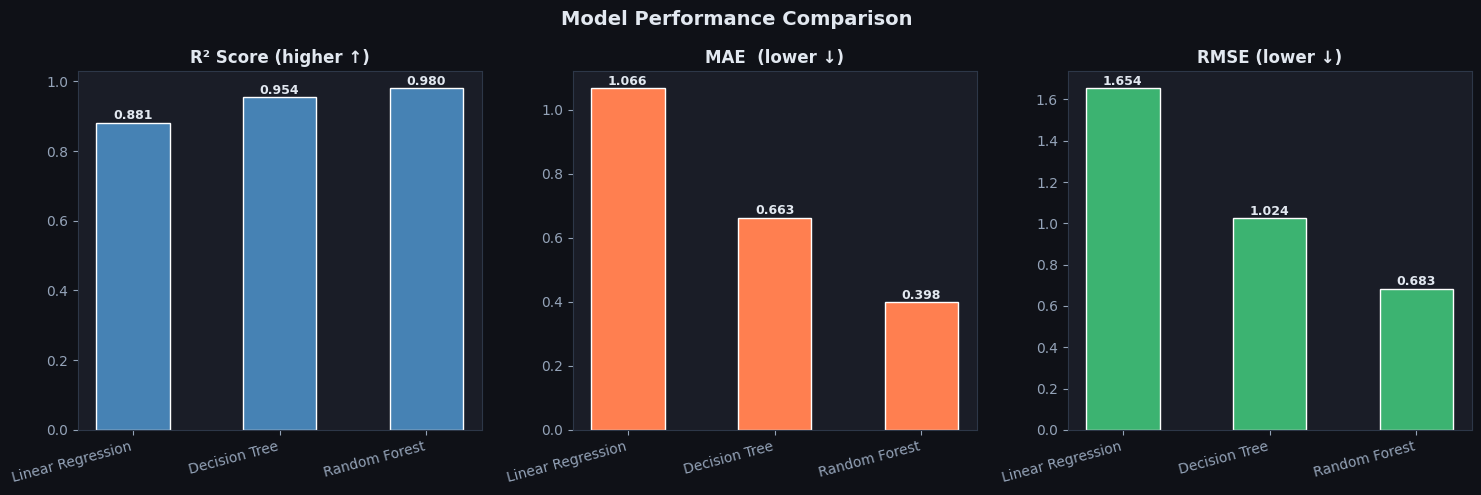

In [194]:
names  = list(results.keys())
r2s    = [results[m]['R2']   for m in names]
maes   = [results[m]['MAE']  for m in names]
rmses  = [results[m]['RMSE'] for m in names]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

for ax, (title, vals, color) in zip(axes, [
    ('R² Score (higher ↑)', r2s,  'steelblue'),
    ('MAE  (lower ↓)',      maes,  'coral'),
    ('RMSE (lower ↓)',      rmses, 'mediumseagreen')]):
    bars = ax.bar(names, vals, color=color, edgecolor='white', width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(names, rotation=15, ha='right')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v + max(vals)*0.01,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Actual vs Predicted & Residuals

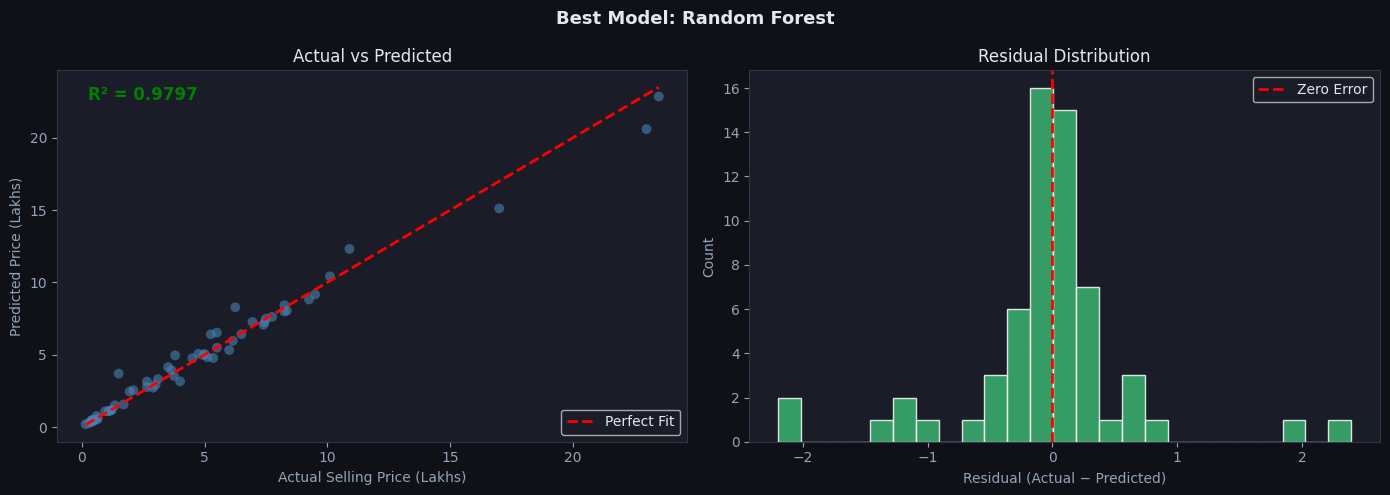

In [195]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Best Model: {best_name}', fontsize=13, fontweight='bold')

bp    = results[best_name]['pred']
resid = y_test.values - bp

# Actual vs Predicted
axes[0].scatter(y_test, bp, alpha=0.6, color='steelblue', s=50, edgecolors='none')
mn, mx = min(y_test.min(), bp.min()), max(y_test.max(), bp.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Fit')
axes[0].set_xlabel('Actual Selling Price (Lakhs)')
axes[0].set_ylabel('Predicted Price (Lakhs)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()
axes[0].text(0.05, 0.92, f'R² = {results[best_name]["R2"]:.4f}',
             transform=axes[0].transAxes, color='green', fontsize=12, fontweight='bold')

# Residuals
axes[1].hist(resid, bins=25, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linewidth=2, linestyle='--', label='Zero Error')
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

## Feature Importance (Random Forest)

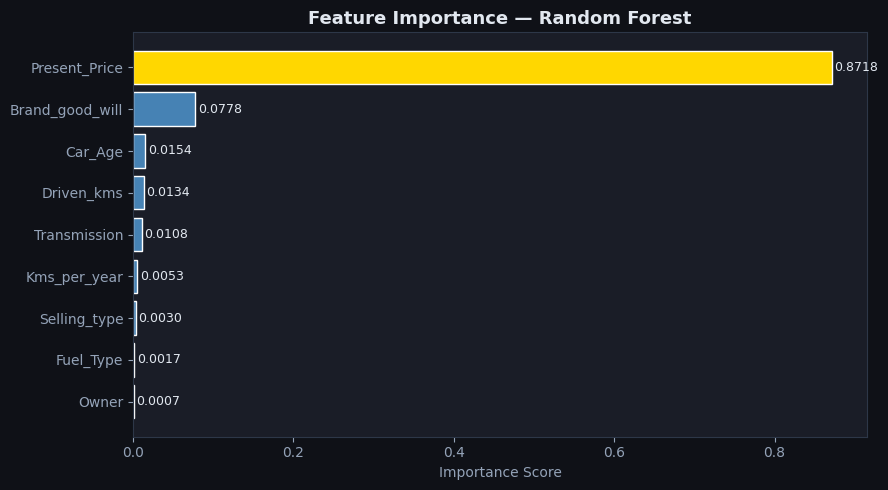

In [196]:
rf = models['Random Forest']
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['gold' if i == len(feat_imp)-1 else 'steelblue' for i in range(len(feat_imp))]
bars = ax.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='white')
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
for bar, val in zip(bars, feat_imp.values):
    ax.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## Predict Price for a New Car

In [197]:
# Example: 2019 Petrol, Dealer, Manual, 30000 KMs, Present Price ₹8L
new_car = pd.DataFrame([{
    'Present_Price':  8.0,
    'Driven_kms':     30000,
    'Car_Age':        2024 - 2019,
    'Fuel_Type':      2,          # Petrol encoded
    'Selling_type':   0,          # Dealer encoded
    'Transmission':   1,          # Manual encoded
    'Owner':          0,
    'Kms_per_year':   30000 / (2024 - 2019 + 1),
    'Brand_good_will':0.75,
}])

print(" Predicted Selling Price (₹ Lakhs):")
print("-"*40)
for name, model in models.items():
    inp = scaler.transform(new_car) if name == 'Linear Regression' else new_car
    price = model.predict(inp)[0]
    marker = "" if name == best_name else ""
    print(f"  {name:<25}: ₹ {price:.2f} Lakhs{marker}")

 Predicted Selling Price (₹ Lakhs):
----------------------------------------
  Linear Regression        : ₹ 6.01 Lakhs
  Decision Tree            : ₹ 5.84 Lakhs
  Random Forest            : ₹ 5.89 Lakhs


## Result

Three machine learning regression models—Linear Regression, Decision Tree Regressor, and Random Forest Regressor—were trained and evaluated for car price prediction. Among all models, the Random Forest Regressor achieved the best performance with:

* R² Score: 0.9797
* MAE: 0.3982
* RMSE: 0.6835

The model was able to predict car selling prices with high accuracy by utilizing features such as present price, vehicle age, driven kilometers, fuel type, transmission type, and ownership details

## Conclusion

This project successfully developed a machine learning-based car price prediction system using Python and Scikit-learn. The dataset was preprocessed, explored through visualizations, and enhanced using feature engineering techniques such as Car Age and Kilometers Driven per Year. Multiple regression models were trained and compared using evaluation metrics including R² Score, MAE, and RMSE.

Among all the models, the Random Forest Regressor produced the most accurate predictions, demonstrating its effectiveness in capturing complex relationships between vehicle characteristics and selling price. The project highlights how machine learning can be applied to real-world automobile valuation problems and supports data-driven decision-making in the used-car market.